In [1]:
import h5py
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.signal import spectrogram, resample_poly

In [3]:
# Load data from file
mat_file_path = 'data/agus2010_cortical.mat'
with h5py.File(mat_file_path, 'r') as file:
    print(list(file.keys()))
    continuous_features = file['features'][:]                     # Shape: [Freq, Time]
    print(list(file['exp_config'].keys()))
    labels = file['exp_config']['labels'][:][0]                   # Shape: [200] (0=N, 1=RN, 2=RefRN)
    onsets = file['exp_config']['trial_onsets_frames'][:][0] - 1  # Convert to 0-indexed Python arrays
    frames_per_trial = int(file['exp_config']['frames_per_trial'][:][0,0])

['#refs#', 'exp_config', 'features', 'final_cfg']
['dur_full', 'frames_per_trial', 'fs_original', 'labels', 'trial_onsets_frames', 'trial_onsets_samples']


In [4]:
continuous_features.shape

(128, 1333334)

In [5]:
labels.shape, onsets.shape

((200,), (200,))

In [6]:
# Get data info
Freq, Time = continuous_features.shape
n_trials = len(labels)
print(f"Slicing {n_trials} trials ({frames_per_trial} frames per trial)...")

Slicing 200 trials (8000 frames per trial)...


In [16]:
# Add noise to data
noise_std = 0.02
cf_w_noise = continuous_features + noise_std*np.random.normal(0, 1, continuous_features.shape)
cf_w_noise.shape

(128, 1333334)

In [25]:
# Slice the continuous stream into discrete 1-second trials

roll_max = 100 # maximum number of time points to offset
trials_list = []
for i in range(n_trials):
    start_idx = int(onsets[i])
    end_idx = start_idx + 6666 #frames_per_trial
   
    # Extract the 1-second segment
    trial_tensor = cf_w_noise[:,start_idx:end_idx]
    
    # Randomly offset refRN data
    if labels[i] == 2:
        nn = random.randrange(roll_max)
        trial_tensor = np.roll(trial_tensor, nn)
    
    trials_list.append(trial_tensor)

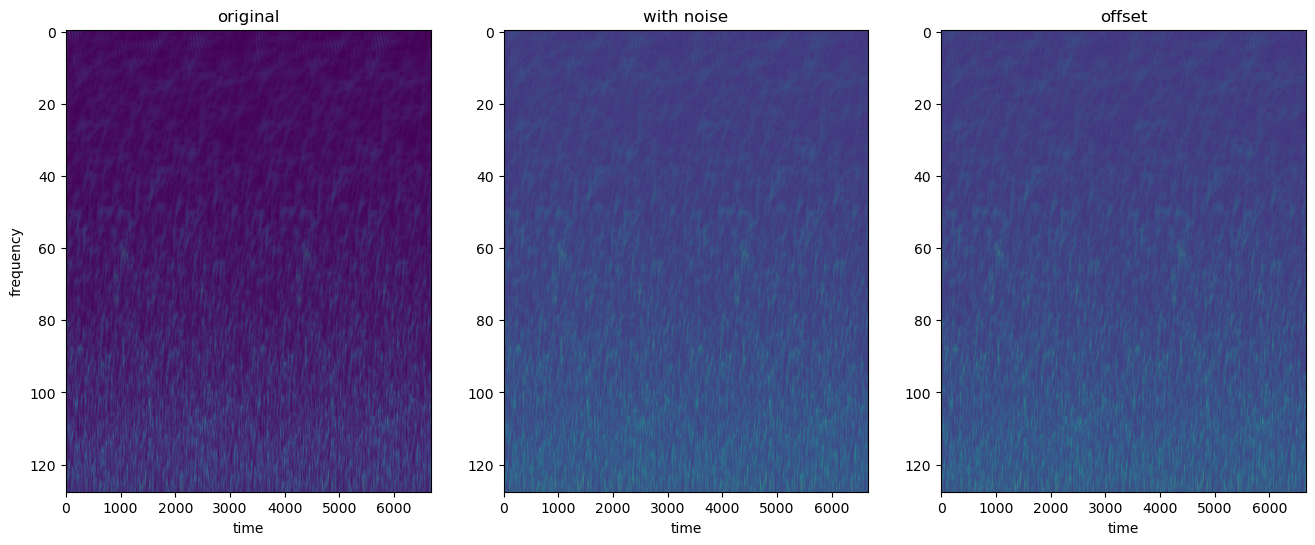

In [26]:
plt.figure(figsize=(16, 6))
plt.subplot(1,3,1)
plt.imshow(continuous_features[:,int(onsets[5]):int(onsets[6])], aspect='auto')
plt.xlabel('time')
plt.ylabel('frequency')
plt.title('original')
plt.subplot(1,3,2)
plt.imshow(cf_w_noise[:,int(onsets[5]):int(onsets[6])], aspect='auto')
plt.xlabel('time')
plt.title('with noise')
plt.subplot(1,3,3)
plt.imshow(trials_list[5], aspect='auto')
plt.xlabel('time')
plt.title('offset')
plt.show()

In [27]:
# Stack into a single numpy array: [Batch, Freq, Time]
batched_np = np.stack(trials_list, axis=0)

In [28]:
# Convert to PyTorch Tensor and format for Conv3D
vae_input = torch.tensor(batched_np, dtype=torch.float32)

In [29]:
print(f"Final VAE Tensor Shape: {vae_input.shape}")

Final VAE Tensor Shape: torch.Size([200, 128, 6666])


In [31]:
# Optional: Create masks for training/testing
mask_N     = (labels == 0)
mask_RN    = (labels == 1)
mask_RefRN = (labels == 2)

In [32]:
print(f"Counts -> N: {mask_N.sum()}, RN: {mask_RN.sum()}, RefRN: {mask_RefRN.sum()}")

Counts -> N: 100, RN: 50, RefRN: 50
